Loading data...
✓ Data loaded: 5209 rows
✓ Data loaded: 5209 rows
✓ Saved cleaned data


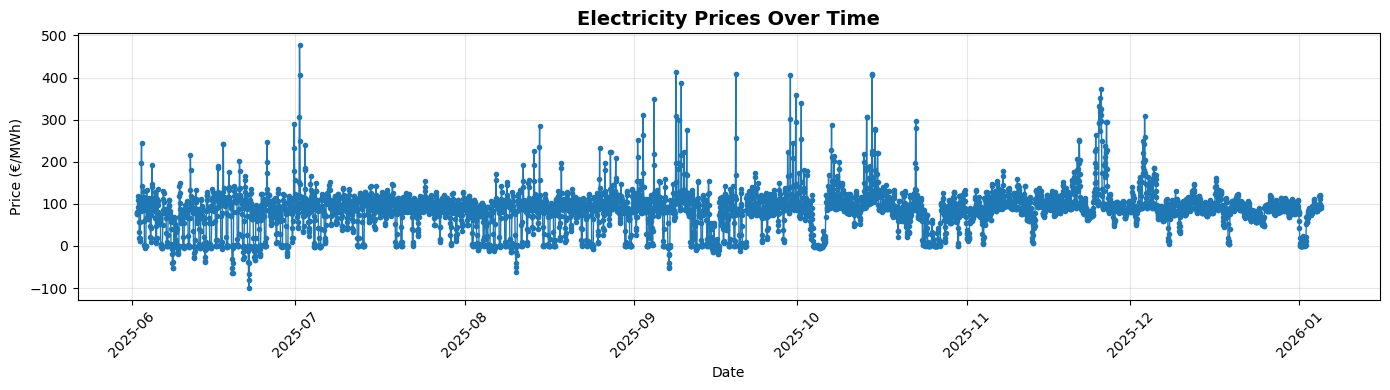

✓ Saved: plots/01_timeseries.png


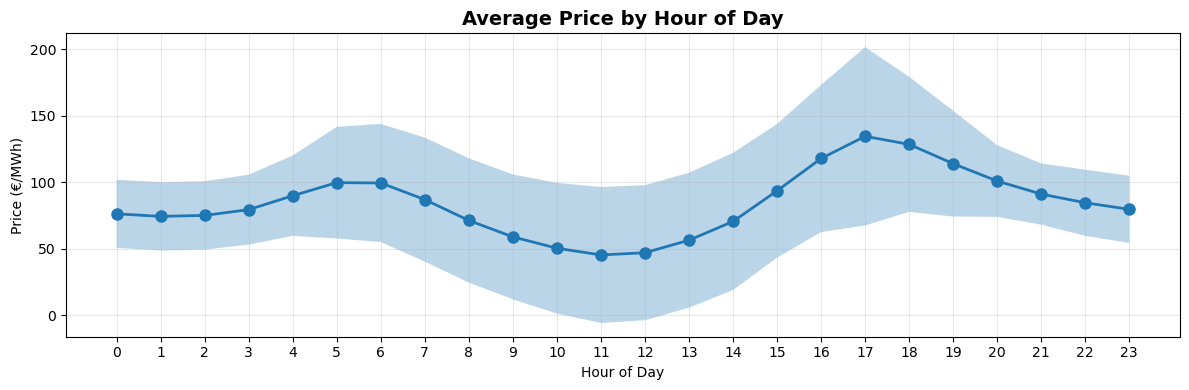

✓ Saved: plots/02_hourly_pattern.png


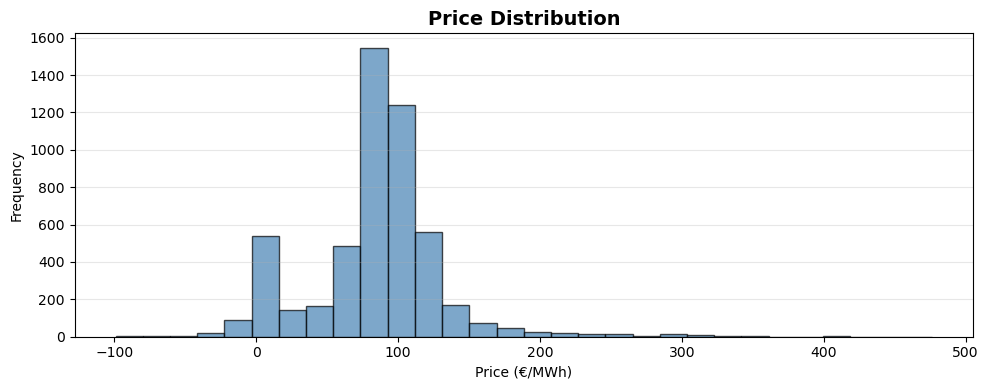

✓ Saved: plots/03_distribution.png


In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# CREATE PLOTS FOLDER 
os.makedirs('plots', exist_ok=True)
os.makedirs('data', exist_ok=True)

print("Loading data...")
df = pd.read_csv('data/electricity_prices.csv')

# Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Ensure numeric price
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Drop missing
df_clean = df.dropna().copy()

# Sort
df_clean = df_clean.sort_values('timestamp').reset_index(drop=True)

print(f"✓ Data loaded: {len(df_clean)} rows")

# Remove NaN values
df_clean = df_clean.dropna()

# Sort by timestamp
df_clean = df_clean.sort_values('timestamp').reset_index(drop=True)

print(f"✓ Data loaded: {len(df_clean)} rows")

# === SAVE CLEANED DATA ===
df_clean.to_csv('data/electricity_prices_clean.csv', index=False)
print(f"✓ Saved cleaned data")

# === PLOT 1: Time Series ===
plt.figure(figsize=(14, 4))
plt.plot(df_clean['timestamp'], df_clean['price'], linewidth=1, marker='o', markersize=3)
plt.title('Electricity Prices Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (€/MWh)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/01_timeseries.png', dpi=150, bbox_inches='tight')  # NOW THIS WORKS!
plt.show()
print("✓ Saved: plots/01_timeseries.png")

# === PLOT 2: Hourly Pattern ===
df_clean['hour'] = df_clean['timestamp'].dt.hour
hourly_avg = df_clean.groupby('hour')['price'].agg(['mean', 'std'])

plt.figure(figsize=(12, 4))
plt.plot(hourly_avg.index, hourly_avg['mean'], marker='o', linewidth=2, markersize=8)
plt.fill_between(hourly_avg.index, 
                 hourly_avg['mean'] - hourly_avg['std'],
                 hourly_avg['mean'] + hourly_avg['std'],
                 alpha=0.3)
plt.title('Average Price by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Price (€/MWh)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/02_hourly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: plots/02_hourly_pattern.png")

# === PLOT 3: Distribution ===
plt.figure(figsize=(10, 4))
plt.hist(df_clean['price'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Price Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Price (€/MWh)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('plots/03_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: plots/03_distribution.png")

